In [124]:
from __future__ import annotations

# <center> **Hierarchial Agglomerative Clustering (HAC) Algorithms** </center>

## **Team Members**

| Name                                             | ID          |
| ------------------------------------------------ | ----------- |
| ANSARI SANAKAUSAR TARIQUE ANSARI SHARMEEN ANSARI | 2024AA05410 |
| G ANIL KUMAR                                     | 2023AA05757 |
| JERIN GEO K                                      | 2024AA05877 |
| NIRMAL J                                         | 2024AA05189 |


In [125]:
# %pip install -q pandas openpyxl nltk python-docx pypdf2

In [126]:
import logging
import math
import string
import sys
from collections import Counter, defaultdict
from functools import cached_property
from pathlib import Path
# Used for generating dendrograms
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import docx
import nltk
import pandas as pd
import PyPDF2
from nltk.corpus import stopwords

# Download necessary package for nltk
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("stopwords", quiet=True)

True

In [127]:
logger = logging.getLogger("DRL")
logger.propagate = False

for handler in logger.handlers:
    logger.removeHandler(handler)

logger.setLevel(logging.INFO)
stream_handler = logging.StreamHandler(sys.stdout)
formatter = logging.Formatter("%(message)s")
stream_handler.setFormatter(formatter)
logger.addHandler(stream_handler)

In [128]:
# A class to represent a processed document with tokens and metadata.
class Document:
    """A class representing a processed document with tokens and optional name."""

    # Creating a class variable to have unique integer ID for all documents in a session
    # Kept as -1 so that count starts from 0
    TOTAL_DOCUMENTS = -1

    def __init__(self, tokens: list[str], text: str, name: str | None = None) -> None:
        """Initialize a Document instance.

        Args:
            tokens (list[str]): List of tokens in the document.
            text (str): The original text of the document.
            name (str | None, optional): The name of the document. Defaults to None.

        """
        self.id_ = self.generate_id()
        self.tokens = tokens
        self.name = name
        self.text = text

    @classmethod
    def generate_id(cls) -> int:
        """Generate a unique ID for each document instance.

        Returns:
            int: The unique document ID.

        """
        cls.TOTAL_DOCUMENTS += 1
        return cls.TOTAL_DOCUMENTS

    def __str__(self) -> str:  # noqa: D105
        return (
            f"Document Name: {self.name}.\n"
            f'{"-" * len(f"Document Name: {self.name}")}\n\n'
            f"Token Count: {len(self.tokens)}.\n"
            f"First 100 Tokens: {self.tokens[:100]}.\n"
        )

In [129]:
# A class with different methods for extracting text information from various document formats.
# The processed documents are stored as instances of the Document class.
class Preprocessor:
    """A class for preprocessing documents for information retrieval tasks."""

    def __init__(self) -> None:  # noqa: D107
        # Getting english stop words
        self._stop_words = {*stopwords.words(fileids="english")}
        # Creating a word net lemmatizer
        # Using lemmatizer as the corpus size for this assignment is less
        self._word_net_lemmatizer = nltk.stem.WordNetLemmatizer()
        self._word_net_lemmatizer = nltk.stem.WordNetLemmatizer()

    def tokenize(self, text: str) -> list[str]:
        """Tokenize the input text into a list of words.

        Args:
            text (str): The text to tokenize.

        Returns:
            list[str]: A list of tokens.

        """
        return nltk.tokenize.word_tokenize(text=text, language="english")

    def lower_case(self, text: str) -> str:
        """Convert the input text to lowercase.

        Args:
            text (str): The text to convert.

        Returns:
            str: The lowercase version of the input text.

        """
        return text.lower()

    def is_punctuation(self, token: str) -> bool:
        """Check if the token is a punctuation character.

        Args:
            token (str): The token to check.

        Returns:
            bool: True if the token is a punctuation character, False otherwise.

        """
        return token in string.punctuation

    def is_stop_word(self, token: str) -> bool:
        """Check if the token is a stop word, excluding 'and', 'not', and 'or'.

        Args:
            token (str): The token to check.

        Returns:
            bool: True if the token is a stop word (excluding 'and', 'not', 'or'), False otherwise.

        """
        # and, not, or are removed so that the functions can be reused  for query processing as well
        return token in self._stop_words - {"and", "not", "or"}

    def lemmatize(self, token: str) -> str:
        """Lemmatize the given token.

        Args:
            token (str): The token to lemmatize.

        Returns:
            str: The lemmatized form of the token.

        """
        return self._word_net_lemmatizer.lemmatize(token)

    def read_text(self, document_path: Path) -> str:
        """Read the contents of a text file.

        Args:
            document_path (Path): The path to the text document.

        Returns:
            str: The contents of the text file as a string.

        """
        with document_path.open("r", encoding="utf-8") as fp:
            return fp.read()

    def read_csv(self, document_path: Path) -> str:
        """Read CSV files and return as space separated strings without the headers.

        Args:
            document_path (Path): The path to the CSV document.

        Returns:
            str: The contents of the CSV file as a space-separated string without headers.

        """
        # Read CSV files as DataFrame and return as space separated strings without the headers
        return pd.read_csv(document_path).to_csv(index=False, header=False, sep=" ")

    def read_excel(self, document_path: Path) -> str:
        """Read Excel files and return as space separated strings without the headers.

        Args:
            document_path (Path): The path to the Excel document.

        Returns:
            str: The contents of the Excel file as a space-separated string without headers.

        """
        return pd.read_excel(document_path).to_csv(index=False, header=False, sep=" ")

    def read_pdf(self, document_path: Path) -> str:
        """Read PDF files and return their text content as a string.

        Args:
            document_path (Path): The path to the PDF document.

        Returns:
            str: The extracted text from the PDF file.

        """
        with document_path.open("rb") as file:
            reader = PyPDF2.PdfReader(file)
            return "\n".join(page.extract_text() or "" for page in reader.pages)

    def read_docx(self, document_path: Path) -> str:
        """Read DOCX files and return their text content as a string.

        Args:
            document_path (Path): The path to the DOCX document.

        Returns:
            str: The extracted text from the DOCX file.

        """
        doc = docx.Document(document_path)
        return "\n".join(paragraph.text for paragraph in doc.paragraphs)

    def read_document(self, document_path: Path) -> str:
        """Read a document based on its file extension.

        Args:
            document_path (Path): The path to the document.

        Returns:
            str: The contents of the document as a string.

        Raises:
            TypeError: If the document type is not supported.

        """
        _read_function_map = {
            ".txt": self.read_text,
            ".xlsx": self.read_excel,
            ".xls": self.read_excel,
            ".csv": self.read_csv,
            ".pdf": self.read_pdf,
            ".docx": self.read_docx,
        }
        document_extension = document_path.suffix

        if document_extension in _read_function_map:
            return _read_function_map[document_extension](document_path=document_path)
        msg = f"{document_extension} document type is not supported."
        raise TypeError(msg)

    def process_document(self, document_path: Path) -> Document:
        """Preprocess a document for indexing.

        Process the document by reading, normalizing, tokenizing, removing stopwords and punctuation,
        lemmatizing, and returning a Document object.

        Returns:
            Document: The processed Document object containing lemmatized tokens.

        """
        logger.info(f"Processing document: {document_path.name}")  # noqa: G004
        text = self.read_document(document_path=document_path)
        lemmatized_tokens = self.process_text(text=text)
        return Document(tokens=lemmatized_tokens, name=document_path.stem, text=text)

    def process_text(self, text: str) -> list[str]:
        """Process raw text by normalizing, tokenizing, removing stopwords and punctuation, and lemmatizing.

        Args:
            text (str): The raw text to process.

        Returns:
            list[str]: List of lemmatized tokens after preprocessing.

        """
        lower_case_text = self.lower_case(text=text)
        replace_punctuations = lower_case_text.translate(str.maketrans("", "", string.punctuation))
        tokens = self.tokenize(text=replace_punctuations)

        # Remove punctuations and stop words
        filtered_tokens = filter(
            lambda token: not (self.is_stop_word(token=token)),
            tokens,
        )

        # Lemmatized words
        final_processed_token = list(map(self.lemmatize, filtered_tokens))
        logger.info(f"Preprocessed tokens: {final_processed_token}")  # noqa: G004
        return final_processed_token

In [130]:
# InvertedIndex class to manage a inverted index for information retrieval and to get the tfidf vector.
class InvertedIndex:
    """A class representing a inverted index for information retrieval.

    This class provides methods to add documents, retrieve posting lists,
    and manage term frequencies for efficient query processing.
    """

    def __init__(self) -> None:  # noqa: D107
        self.index = defaultdict(list)
        self.document_frequency = defaultdict(int)
        self.number_of_documents = 0
        self.documents = {}
        self.tfidfs = {}

    @classmethod
    def from_documents(cls, documents: list[Document]) -> InvertedIndex:
        """Create an InvertedIndex from a list of documents.

        Args:
            documents (list[Document]): The list of documents to index.

        Returns:
            InvertedIndex: An instance of InvertedIndex containing the indexed documents.

        """
        index = cls()
        for doc in documents:
            index.add_document(doc)
        index.sort()
        return index

    def add_document(self, document: Document) -> None:
        """Add a document to the inverted index.

        Args:
            document (Document): The document to be added to the index.

        """
        document_length_square = 0
        # Iterate through the tokens to update the index
        for term, term_frequency in Counter(document.tokens).items():
            # Add the term and frequency to the inverted index
            self.index[term].append(document.id_)
            # Update the document frequency
            self.document_frequency[term] += 1
            # Update the document length square
            document_length_square += math.pow(term_frequency, 2)

        self.number_of_documents += 1
        self.documents[document.id_] = document

    def sort(self) -> None:
        """Sort the inverted index."""
        sorted_index = defaultdict(list)
        sorted_terms = sorted(self.index.items())
        for term, posting_list in sorted_terms:
            sorted_index[term] = sorted(posting_list)
        self.index = sorted_index

    def _get_tfidf_vector(self, document: Document) -> pd.Series:
        """Return the TF-IDF vector for a given document.

        pandas Series is used to store the TF-IDF scores for each term.
        This is to reduce the dimensionality of the document representation.

        Args:
            document (Document): The document to retrieve the TF-IDF vector for.

        Returns:
            pd.Series: A pandas Series mapping terms to their TF-IDF scores.

        """
        tfidf = pd.Series(dtype=float)
        for term, term_frequency in Counter(document.tokens).items():
            tf = 1 + math.log10(term_frequency) if term_frequency > 0 else 0
            idf = self._get_idf(term)
            tfidf[term] = tf * idf

        # Normalize the TF-IDF vector
        return (tfidf / math.sqrt((tfidf * tfidf).sum())).sort_index()

    def _get_idf(self, term: str) -> float:
        """Calculate the Inverse Document Frequency (IDF) for a given term.

        Args:
            term (str): The term to calculate the IDF for.

        Returns:
            float: The IDF score for the term.

        """
        if term not in self.document_frequency:
            return 0.0
        return math.log10(self.number_of_documents / self.document_frequency[term])

    # Use cached property to avoid recalculating the tfidf matrix every time
    @cached_property
    def tfidf_matrix(self) -> dict[int, pd.Series]:
        """Return the TF-IDF matrix for all documents in the index.

        Returns:
            dict[int, pd.Series]: A dictionary mapping document IDs to their TF-IDF vectors.

        """
        tfidf_matrix = {}
        for doc_id, document in self.documents.items():
            tfidf_matrix[doc_id] = self._get_tfidf_vector(document)
        return tfidf_matrix

    def __str__(self) -> str:
        """Represent the InvertedIndex as a string."""
        # Table representation of the inverted index
        table = []
        for term, postings in self.index.items():
            table.append(f"{term}: {postings}")
        return "\n".join(table)


## **Inverted Index**


In [131]:
preprocessor = Preprocessor()

# Update in document path might be required based on the actual location of the medical documents
# Drive location "/content/drive/MyDrive/Assignment_1_IR/data/medical-documents/"
# Local location "./data/medical-documents/"
documents = [
    preprocessor.process_document(document_path=document_path)
    for document_path in Path("./data/news-articles/").iterdir()
]
inverted_index = InvertedIndex.from_documents(documents=documents)


Processing document: 2022-wnba-finals.txt
Preprocessed tokens: ['la', 'vega', 'ace', 'win', 'first', 'wnba', 'title', 'chelsea', 'gray', 'named', 'mvp', 'la', 'vega', 'never', 'professional', 'sport', 'champion', '—', 'sunday']
Processing document: american-airlines-passenger-banned-flight-attendant-punch-justice-department.txt
Preprocessed tokens: ['american', 'airline', 'flyer', 'charged', 'banned', 'life', 'punching', 'flight', 'attendant', 'video', 'subdued', 'passenger', 'and', 'crew', 'fled', 'back', 'aircraft', 'confrontation', 'according', 'u', 'attorney', 'office', 'los', 'angeles']
Processing document: amy-cooper-loses-discrimination-lawsuit-franklin-templeton.txt
Preprocessed tokens: ['woman', 'called', 'cop', 'black', 'birdwatcher', 'loses', 'lawsuit', 'exemployer', 'amy', 'cooper', 'accused', 'investment', 'firm', 'franklin', 'templeton', 'unfairly', 'firing', 'and', 'branding', 'racist', 'video', 'central', 'park', 'encounter', 'went', 'viral']
Preprocessed tokens: ['la',

In [132]:
logger.info(f"Total documents processed: {Document.TOTAL_DOCUMENTS}")  # noqa: G004
logger.info(f"Total terms in the index: {len(inverted_index.index)}")  # noqa: G004

Total documents processed: 29
Total terms in the index: 534
Total terms in the index: 534


In [133]:
# Display the positional inverted index
logger.info("Positional Inverted Index:")
logger.info(str(inverted_index))

Positional Inverted Index:
171: [7]
1723: [11, 12]
18: [13]
187: [28]
200000: [26]
2000s: [14]
2009: [17]
2020: [19]
206: [27]
23: [12]
3: [15]
4: [4, 7, 9, 25]
437day: [28]
60th: [10]
63yearold: [4]
7075: [28]
80: [28]
87: [13]
89: [8]
abe: [18]
accidentally: [11]
according: [1]
accused: [2]
ace: [0]
adorable: [24]
affront: [5]
afghanistan: [19]
age: [29]
ai: [29]
air: [21]
aircraft: [1]
airline: [1]
alain: [10]
american: [1, 7, 19]
among: [23]
amy: [2]
anchor: [24]
and: [1, 2, 5, 9, 10, 11, 12, 14, 15, 16, 19, 20, 23, 25, 27, 28, 29]
angeles: [1, 8]
animal: [29]
annual: [27]
antibiotic: [29]
apparent: [18]
armband: [3]
artificial: [29]
asked: [24]
aspect: [17]
atombyatom: [29]
attempt: [29]
attendant: [1]
attorney: [1]
authority: [4]
avatar: [17]
back: [1]
bacteria: [29]
ban: [26]
banned: [1]
barrel: [15]
basestealing: [8]
bathroom: [4]
bear: [16]
beautiful: [27]
become: [9, 29]
behind: [24, 29]
belk: [4]
bermuda: [9]
biden: [5, 6, 23]
birdwatcher: [2]
birthday: [10]
black: [2, 13]
b

In [134]:
tfidf_matrix = inverted_index.tfidf_matrix
logger.info("TF-IDF Matrix:\n")
for document_id, tfidf in tfidf_matrix.items():
    tab = "\t"
    logger.info(f"Document ID: {document_id:02d}\n")  # noqa: G004
    logger.info(f"{tab.join([ str(key).center(15) for key, _ in tfidf.items()])}")  # noqa: G004
    logger.info(f"{tab.join([str(round(value, 4)).center(15) for _, value in tfidf.items()])}\n")  # noqa: G004


TF-IDF Matrix:

Document ID: 00

      ace      	    champion   	    chelsea    	     first     	      gray     	       la      	      mvp      	     named     	     never     	  professional 	     sport     	     sunday    	     title     	      vega     	      win      	      wnba     	       —       
     0.2458    	     0.2458    	     0.2458    	     0.1957    	     0.2458    	     0.3198    	     0.2458    	     0.2458    	     0.2458    	     0.2458    	     0.2458    	     0.1957    	     0.1957    	     0.3198    	     0.1957    	     0.2458    	     0.1957    

Document ID: 01

   according   	    aircraft   	    airline    	    american   	      and      	    angeles    	   attendant   	    attorney   	      back     	     banned    	    charged    	 confrontation 	      crew     	      fled     	     flight    	     flyer     	      life     	      los      	     office    	   passenger   	    punching   	    subdued    	       u       	     video     
     0.2196    	     

## **Document Similarity**


In [135]:
def cosine_similarity(tfidf1: pd.Series, tfidf2: pd.Series) -> float:
    """Compute the cosine similarity between two TF-IDF vectors."""
    # The two vectors are already normalized
    # Therefore, we can use the dot product directly
    intersection = tfidf1.index.intersection(tfidf2.index)
    if len(intersection) == 0:
        return 0.0
    return tfidf1.loc[intersection].dot(tfidf2.loc[intersection])


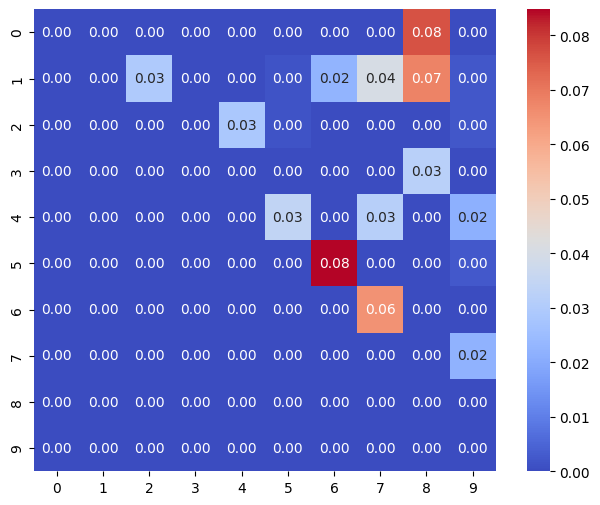

In [136]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Select first 10 documents only to show similarity
similarity_matrix = np.zeros((10, 10))

for row in range(10):
    # Only compute upper triangle
    for col in range(row, 10):
        if row != col:
            similarity_matrix[row, col] = cosine_similarity(tfidf_matrix[row], tfidf_matrix[col])
        else:
            similarity_matrix[row, col] = 0

plt.figure(figsize=(8, 6), dpi=100)
sns.heatmap(data=similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.show()

## **Hierarchical Clustering**


### **Single Link**


Clusters: [13 19 29 24  1 16 17 20 15  7 30 11 12  3 28  8  9 22  5 25 23  2 10 14
  4 18  6 21 26 27]


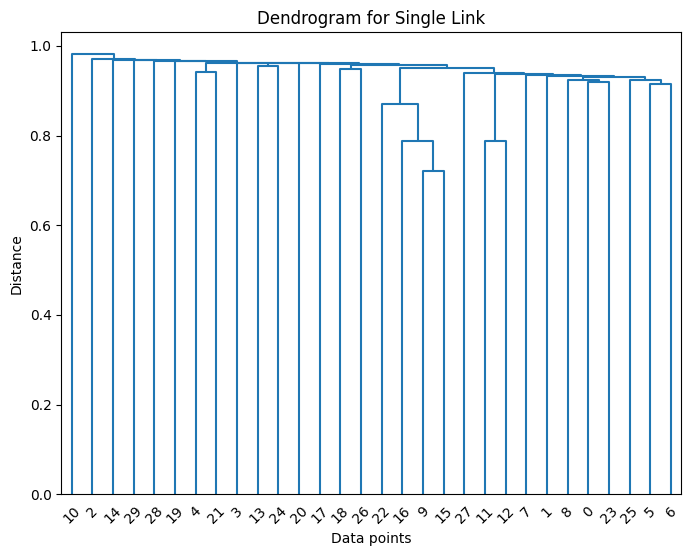

In [137]:
def single_link(tfidf_matrix: dict[int, pd.Series], *, plot=False) -> None:
    """Perform single-link hierarchical clustering."""
    # Convert the TF-IDF matrix to a DataFrame so that all the vectors have same dimension
    df = pd.DataFrame(tfidf_matrix).fillna(0).transpose()
    # Perform hierarchical clustering
    linked = linkage(df, method='single', metric="cosine")
    if plot:

        # For logging flattened clusters with a distance threshold
        clusters = fcluster(linked, t=0.5, criterion='distance')
        logger.info(f"Clusters: {clusters}")

        plt.figure(figsize=(8, 6), dpi=100)
        dendrogram(linked, truncate_mode="level")

        plt.title("Dendrogram for Single Link")
        plt.xlabel("Data points")
        plt.ylabel("Distance")

        plt.show()


single_link(tfidf_matrix, plot=True)

### **Complete Link**


Clusters: [17 28 14 30 19 23 24 26 29  4 13  9 10  1 27  5  6 21 15 25 22 20  7 18
  2 11 16 12  8  3]


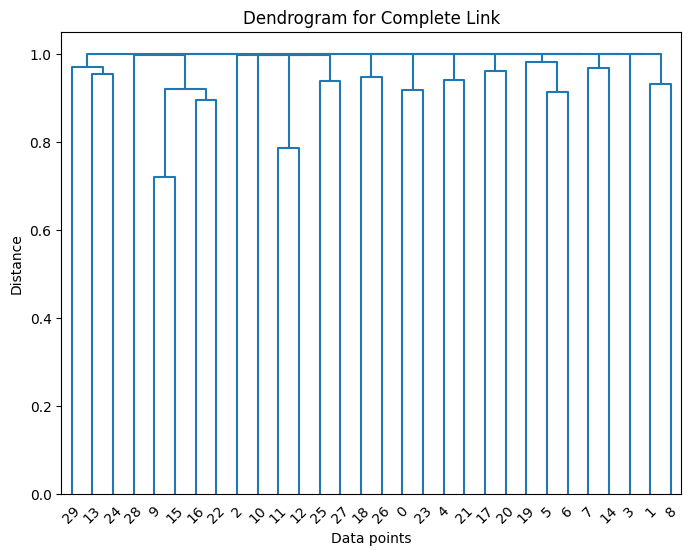

In [138]:
def complete_link(tfidf_matrix: dict[int, pd.Series], *, plot=False) -> None:
    """Perform complete-link hierarchical clustering."""
    # Convert the TF-IDF matrix to a DataFrame so that all the vectors have same dimension
    df = pd.DataFrame(tfidf_matrix).fillna(0).transpose()
    # Perform hierarchical clustering
    linked = linkage(df, method='complete', metric='cosine')

    if plot:
        # For logging flattened clusters with a distance threshold
        clusters = fcluster(linked, t=0.5, criterion='distance')
        logger.info(f"Clusters: {clusters}")

        plt.figure(figsize=(8, 6), dpi=100)
        dendrogram(linked, truncate_mode="level")

        plt.title("Dendrogram for Complete Link")
        plt.xlabel("Data points")
        plt.ylabel("Distance")

        plt.show()


complete_link(tfidf_matrix, plot=True)

### **Centroid Link**


Clusters: [23 21 25 28  8  9  6  5 22  1 30 17 18 15 29  2  3  7 26 16 24 14  4 13
 19 10 27 11 20 12]


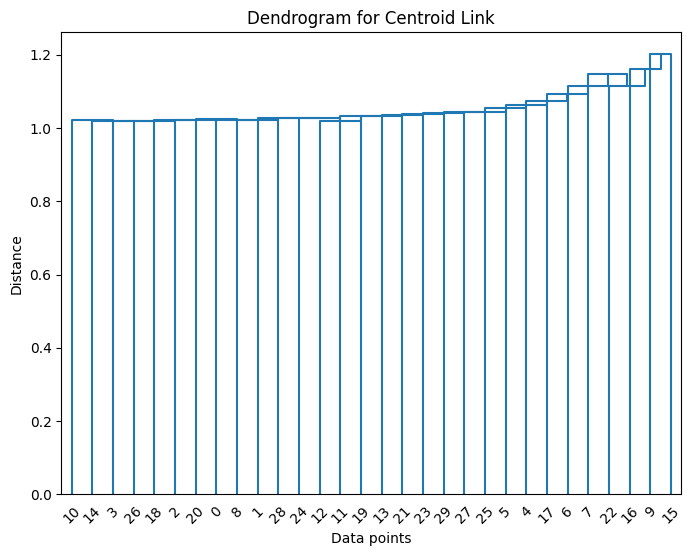

In [139]:
def centroid_link(tfidf_matrix: dict[int, pd.Series], *, plot=False) -> None:
    """Perform centroid-link hierarchical clustering."""
    # Convert the TF-IDF matrix to a DataFrame so that all the vectors have same dimension
    df = pd.DataFrame(tfidf_matrix).fillna(0).transpose()
    # Perform hierarchical clustering
    linked = linkage(df, method='centroid')

    if plot:
        # For logging flattened clusters with a distance threshold
        clusters = fcluster(linked, t=0.5, criterion='distance')
        logger.info(f"Clusters: {clusters}")
        
        plt.figure(figsize=(8, 6), dpi=100)
        dendrogram(linked, truncate_mode="level")

        plt.title("Dendrogram for Centroid Link")
        plt.xlabel("Data points")
        plt.ylabel("Distance")

        plt.show()


centroid_link(tfidf_matrix, plot=True)

### **Group Average Link**


Clusters: [ 3  5  8  7 17 19 20 21  6  9 30 13 14 25 29 10 11 23  1 22 24 18 12  4
 26 15  2 16 28 27]


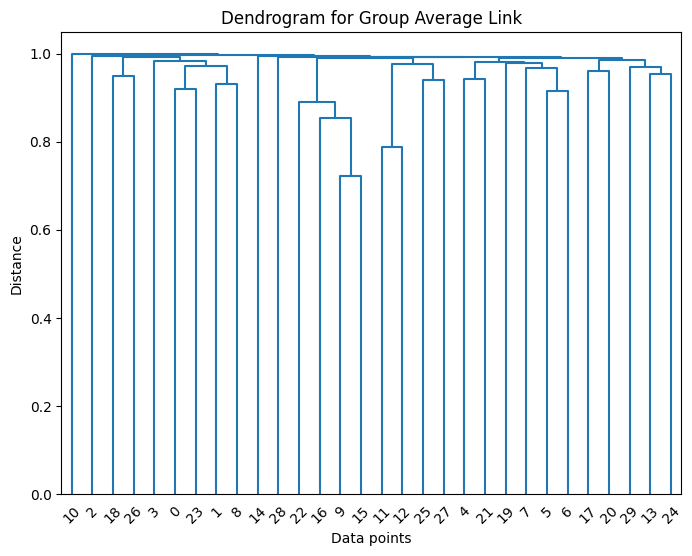

In [140]:
def group_average_link(tfidf_matrix: dict[int, pd.Series], *, plot=False) -> None:
    """Perform group-average hierarchical clustering."""
    # Convert the TF-IDF matrix to a DataFrame so that all the vectors have same dimension
    df = pd.DataFrame(tfidf_matrix).fillna(0).transpose()
    # Perform hierarchical clustering
    linked = linkage(df, method='average', metric='cosine')
    if plot:
        
        # For logging flattened clusters with a distance threshold
        clusters = fcluster(linked, t=0.5, criterion='distance')
        logger.info(f"Clusters: {clusters}")

        plt.figure(figsize=(8, 6), dpi=100)
        dendrogram(linked, truncate_mode="level")

        plt.title("Dendrogram for Group Average Link")
        plt.xlabel("Data points")
        plt.ylabel("Distance")

        plt.show()


group_average_link(tfidf_matrix, plot=True)

## **Pros and Cons**

### Single Link

- **How**: min pairwise distance between clusters.
- **Pros**: Finds elongated/chain-shaped structures; tolerant of local high similarity (good when articles are connected via bridging topics).
- **Cons**: Chaining effect; a series of moderately similar docs can glue together different topics; very sensitive to noise bridge.

### Complete Link

- **How**: max pairwise distance.
- **Pros**: Produces compact, tight clusters; reduces chaining; good when you want topical purity.
- **Cons**: Sensitive to outliers; a single odd doc can prevent two otherwise similar groups from merging until very high distances; can fragment topics with natural sub-themes.

### Group-Average Link

- **How**: average pairwise distances between clusters.
- **Pros**: Balanced between single and complete; usually robust for cosine on TF-IDF; less sensitive to outliers than complete, less chaining than single; very common for text.
- **Cons**: Can slightly blur sharp topic boundaries if topics have uneven sizes.

### Centroid Link

- **How**: distance between cluster centroids.
- **Pros**: Fast and intuitive; centroids often meaningful with TF-IDF (prototype topics).
- **Cons**: Can cause inversions (non-monotonic dendrogram heights); sensitive to centroid drift—two compact clusters can merge earlier than expected if centroids align, even when max pairwise distance is large.

---

## Recommendation for similar news datasets

**Complete Link & Group-Average Link**: From the above diagrams, the group average link and complete link show the most promising result. The image is clean and shows clear cut levels of clusters.
For sparse TF-IDF + cosine, group average link typically yields the most stable, interpretable clusters without chaining and with reasonable tolerance to outliers. Dendrogram cut levels are more reliable, and topic coherence is good in practice. So, generally group average should be used.
